# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


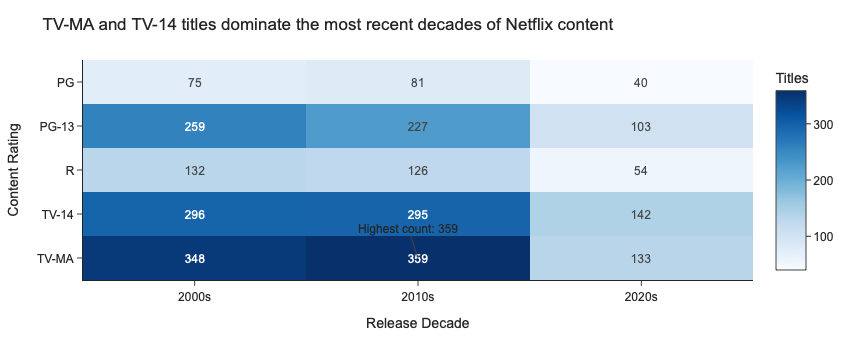

In [3]:
# Task 1
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Keep only the most common ratings
ratings_keep = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

heat_df = df[df['rating'].isin(ratings_keep)]

# Create pivot table
heatmap_data = (
    heat_df
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

pivot = heatmap_data.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

# Heatmap
fig = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto'
)

# Find largest cell for annotation
max_row, max_col = pivot.stack().idxmax()
max_value = pivot.loc[max_row, max_col]

fig.add_annotation(
    x=max_col,
    y=max_row,
    text=f'Highest count: {int(max_value)}',
    showarrow=True
)

fig.update_layout(
    title='TV-MA and TV-14 titles dominate the most recent decades of Netflix content',
    template='simple_white',
    font=dict(family='Arial'),
    xaxis_title='Release Decade',
    yaxis_title='Content Rating',
    coloraxis_colorbar_title='Titles'
)

fig.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


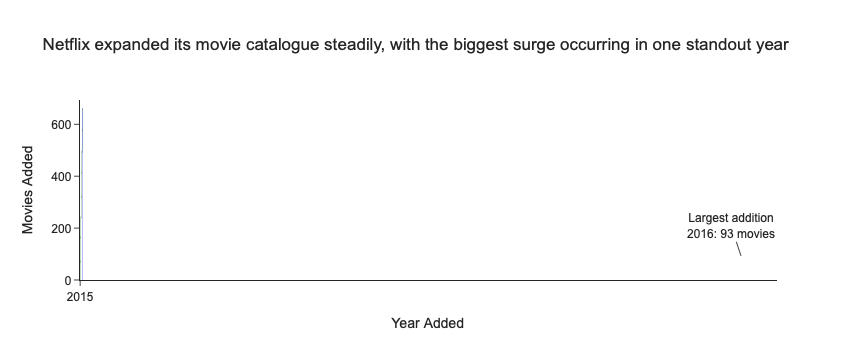

In [4]:
# Task 2
# YOUR CODE HERE
import plotly.graph_objects as go

# Movies only
movies = df[df['type'] == 'Movie']

# Count movie additions by year
yearly_additions = (
    movies.groupby('added_year')
    .size()
    .reset_index(name='count')
)

# Keep 2015–2022
yearly_additions = yearly_additions[
    (yearly_additions['added_year'] >= 2015) &
    (yearly_additions['added_year'] <= 2022)
].sort_values('added_year')

# Find year with largest addition
max_row = yearly_additions.loc[yearly_additions['count'].idxmax()]
max_year = int(max_row['added_year'])
max_count = int(max_row['count'])

# Waterfall chart
fig = go.Figure(go.Waterfall(
    name='Movies',
    orientation='v',
    measure=['relative'] * len(yearly_additions) + ['total'],
    x=[str(y) for y in yearly_additions['added_year']] + ['Total'],
    y=yearly_additions['count'].tolist() + [0],

    increasing=dict(marker=dict(color='green')),
    decreasing=dict(marker=dict(color='red')),
    totals=dict(marker=dict(color='blue'))
))

# Annotation for largest addition year
fig.add_annotation(
    x=str(max_year),
    y=max_count,
    text=f'Largest addition<br>{max_year}: {max_count} movies',
    showarrow=True
)

fig.update_layout(
    title='Netflix expanded its movie catalogue steadily, with the biggest surge occurring in one standout year',
    template='simple_white',
    font=dict(family='Arial'),
    xaxis_title='Year Added',
    yaxis_title='Movies Added'
)

fig.show()